# Deep Hedging: Section 4.2 Replication
## Benchmarking Without Transaction Costs (Black-Scholes Model)

**Based on:** Buehler, Gonon, Teichmann, Wood, Mohan & Kochems (2019)  
*"Deep Hedging: Hedging Derivatives Under Generic Market Frictions Using Reinforcement Learning"*

---

We reproduce the benchmarking experiment of Section 4.2 of Buehler et al. (2019) with two changes. First, the market model: we use **Black-Scholes** instead of Heston, so there is one source of risk (constant volatility) and one hedging instrument (equity only). Second, the framework: PyTorch instead of TensorFlow.

Everything else follows the paper exactly:

| Hyperparameter | Paper (Setting 1) | This notebook |
|---|---|---|
| Time horizon | 30 trading days | 30 trading days |
| Rebalancing | Daily | Daily |
| Network depth | 2 hidden layers | 2 hidden layers |
| Hidden width | 15 | 15 |
| Activation | ReLU throughout | ReLU throughout |
| Optimizer | Adam | Adam |
| Learning rate | 0.005 | 0.005 |
| Batch size | 256 | 256 |
| Risk measure | CVaR(50%) | CVaR(50%) |
| Transaction costs | None | None |
| Network architecture | Separate net per time step | Separate net per time step |

### Network architecture and action-position distinction

The paper uses one independent feed-forward network per time step with its own learned weights $\mathbf{w}_t$. Each network outputs the **trading action** $a^\pi_t$ which denote the units to buy (positive) or sell (negative) at time $t$. The resulting **position** is:

$$\delta^\pi_t = a^\pi_t + \delta^\pi_{t-1}, \qquad \delta^\pi_{-1} = 0$$

Because network $t$ is only ever called at its own fixed time step, it implicitly encodes remaining time to maturity through its learned weights with no explicit time input needed. The two architectures differ only in what market information enters $s_t$:

| Architecture | Input $s_t$ at step $t$ | Output | Input dim |
|---|---|---|---|
| **Simple** | $\log(S_t/K)$ | $a^\pi_t$ (action) | 1 |
| **Recurrent** | $\bigl[\log(S_t/K),\; \delta^\pi_{t-1}\bigr]$ | $a^\pi_t$ (action) | 2 |

The Recurrent network receives the **position** $\delta_{t-1}$ (not the previous action $a_{t-1}$) as part of its input. This gives it the information needed to decide by how much to adjust its exposure.

### The deep hedging objective

The terminal net P&L uses the **position** $\delta^\pi_t$ (not the action $a^\pi_t$):

$$G^\pi = \underbrace{\sum_{t=0}^{T-1} \delta^\pi_t\,(S_{t+1} - S_t)}_{\text{hedge P\&L (position × price change)}} - \underbrace{(S_T - K)^+}_{\text{option payoff}}, \qquad \delta^\pi_t = a^\pi_t + \delta^\pi_{t-1}$$

We seek the policy that maximises the **CVaR(50%) risk-adjusted return**:

$$\pi^* = \arg\max_\pi \;\mathrm{CVaR}_{0.5}(G^\pi), \qquad \mathrm{CVaR}_\alpha(G) = \sup_{w}\left\{w - \tfrac{1}{1-\alpha}\,\mathbb{E}[(w-G)^+]\right\}$$

---

## 0. Imports and Global Parameters

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm
import time
import warnings
warnings.filterwarnings('ignore')

# ── Market parameters ──────────────────────────────────────────────────────────
S0    = 100.0   # initial stock price
K     = 100.0   # strike (ATM call: K = S0)
RATE  = 0.0     # risk-free rate (paper: flat rates, r = 0)
SIGMA = 0.20    # annual volatility
N_STEPS = 30    # trading days = rebalancing steps
T     = N_STEPS / 252.0   # option maturity in years
DT    = T / N_STEPS       # one day in years = 1/252

# ── Learning parameters — matches paper Section 4.1 Setting 1 ──────────────────
ALPHA   = 0.50     # CVaR level: 50%  =>  λ = 1/(1−α) = 2
N_TRAIN = 500_000  # training paths  (paper uses 4 × 10^6)
N_TEST  = 100_000  # out-of-sample paths  (paper uses 10^6)
BATCH   = 256      # mini-batch size  (matches paper)
LR      = 0.005    # Adam learning rate  (matches paper)
N_ITER  = 100_000  # gradient steps
HIDDEN  = 15       # hidden-layer width  (matches paper)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'S0={S0}, K={K}, σ={SIGMA}, r={RATE}')
print(f'T = {N_STEPS} trading days ({T:.4f} yr),  Δt = 1/252 yr')

Device : cpu
S0=100.0, K=100.0, σ=0.2, r=0.0
T = 30 trading days (0.1190 yr),  Δt = 1/252 yr


## 1. Black-Scholes Market

### 1.1 Closed-form benchmarks

The **Black-Scholes call price** and **delta** serve as the theoretical benchmarks:

$$C(S,\tau) = S\,N(d_1) - K\,e^{-r\tau}N(d_2), \qquad d_1 = \frac{\ln(S/K)+(r+\frac{\sigma^2}{2})\tau}{\sigma\sqrt{\tau}},\quad d_2 = d_1 - \sigma\sqrt{\tau}$$

$$\Delta^{\mathrm{BS}}(S,\tau) = N(d_1)$$

In continuous time the BS delta achieves perfect replication. With daily rebalancing, small hedging errors accumulate, giving a strictly negative CVaR. This is the baseline our networks compete against.

### 1.2 Path simulation

Under the risk-neutral measure $\mathbb{Q}$, the stock follows geometric Brownian motion:

$$S_{t+1} = S_t \exp\!\Bigl[(r - \tfrac{1}{2}\sigma^2)\Delta t + \sigma\sqrt{\Delta t}\,Z_t\Bigr], \quad Z_t \overset{\text{i.i.d.}}{\sim}\mathcal{N}(0,1)$$

In [3]:
def bs_call_price(S, K, r, sigma, tau):
    """Black-Scholes European call price."""
    if tau < 1e-12:
        return float(max(S - K, 0.0))
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    d2 = d1 - sigma * np.sqrt(tau)
    return float(S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2))


def bs_delta_vec(S_arr, K, r, sigma, tau):
    """Vectorised BS call delta over an array of spot prices."""
    if tau < 1e-12:
        return (S_arr > K).astype(float)
    d1 = (np.log(S_arr / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
    return norm.cdf(d1)


def simulate_paths(S0, r, sigma, T, N_steps, N_paths, seed=None):
    """
    Simulate GBM paths under the risk-neutral measure Q.
    Returns a float32 tensor of shape (N_paths, N_steps + 1) on DEVICE.
    """
    if seed is not None:
        torch.manual_seed(seed)
    dt  = T / N_steps
    Z   = torch.randn(N_paths, N_steps, device=DEVICE)
    inc = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    log_S = np.log(S0) + torch.cumsum(inc, dim=1)
    S0_col = torch.full((N_paths, 1), S0, device=DEVICE)
    return torch.cat([S0_col, torch.exp(log_S)], dim=1)   # (N, T+1)


# ── Sanity check: simulated mean payoff should equal BS price ──────────────────
model_price = bs_call_price(S0, K, RATE, SIGMA, T)
S_chk   = simulate_paths(S0, RATE, SIGMA, T, N_STEPS, 200_000, seed=0)
pay_chk = torch.relu(S_chk[:, -1] - K).mean().item()
print(f'Black-Scholes call price (30-day ATM) : {model_price:.4f}')
print(f'Simulated payoff mean (200 K paths)   : {pay_chk:.4f}  '
      f'[should be ≈ {model_price:.4f}]')

Black-Scholes call price (30-day ATM) : 2.7524
Simulated payoff mean (200 K paths)   : 2.7502  [should be ≈ 2.7524]


## 2. Network Architectures

The key architectural choice is one independent feed-forward network per time step. At step $t$, network $t$ outputs the trading action $a^\pi_t = \hat{a}^{\mathbf{w}_t}_t(s_t)$, and the cumulative position is $\delta^\pi_t = a^\pi_t + \delta^\pi_{t-1}$. The same three-layer topology is used at every step:

$$s_t \xrightarrow{\;W^{(1)}_t,\,b^{(1)}_t\;} \mathbb{R}^{15} \xrightarrow{\mathrm{ReLU}} \xrightarrow{\;W^{(2)}_t,\,b^{(2)}_t\;} \mathbb{R}^{15} \xrightarrow{\mathrm{ReLU}} \xrightarrow{\;W^{(3)}_t,\,b^{(3)}_t\;} \mathbb{R} \;=\; a^\pi_t$$

Because network $t$ is only ever evaluated at time step $t$, it implicitly encodes the remaining time to maturity $\tau_t$ through its learned weights, no explicit time input is required.

Parameter count per time step: $(1 \times 15 + 15) + (15 \times 15 + 15) + (15 \times 1 + 1) = 286$ (Simple) or $301$ (Recurrent). Total: $30 \times 286 = 8\,580$ (Simple), $30 \times 301 = 9\,030$ (Recurrent).

### Gradient flow in the Recurrent network

In the Recurrent network the input at time $t$ includes $\delta^\pi_{t-1}$, which itself depends on network $t-1$. Gradients therefore flow backward through time (BPTT-style): the loss at $T$ informs the net at $t$ both directly through $\delta^\pi_t \cdot \Delta S_t$ and indirectly through $\delta^\pi_t$'s role as the input component received by the net at ${t+1}$.

In [4]:
def make_ffn(n_in, hidden=HIDDEN):
    """3-layer FC network: n_in → hidden → hidden → 1 (ReLU on hidden layers, linear output)."""
    return nn.Sequential(
        nn.Linear(n_in, hidden), nn.ReLU(),
        nn.Linear(hidden, hidden), nn.ReLU(),
        nn.Linear(hidden, 1),
    )


class SimpleHedger(nn.Module):
    """
    Paper's Simple network (Section 3.2, label "Simple").

    One independent FFN per time step; weights NOT shared across steps.
    Input at step t:  log(S_t / K)   — dimension 1.
    Output at step t: a_t (trading action — units bought/sold at time t).
    Position:         δ_t = a_t + δ_{t-1},  δ_{-1} = 0.

    Because network t is only ever called at that specific step, it
    implicitly encodes the remaining time τ_t through its weights.
    No explicit time input is needed.
    """
    def __init__(self, N_steps=N_STEPS, hidden=HIDDEN):
        super().__init__()
        self.nets = nn.ModuleList([make_ffn(n_in=1, hidden=hidden)
                                   for _ in range(N_steps)])

    def forward(self, S):
        """
        Roll out the hedge over all time steps.
        S       : (N, N_steps+1)  stock-price tensor
        Returns : (pnl, deltas)
            pnl    — (N,)          terminal hedging P&L (excl. option payoff)
            deltas — list of (N,)  position δ_t = a_t + δ_{t-1} at each step
        """
        N          = S.shape[0]
        pnl        = torch.zeros(N, device=S.device)
        delta      = torch.zeros(N, device=S.device)   # δ_{-1} = 0
        deltas     = []
        for t, net in enumerate(self.nets):
            x     = (S[:, t] / K).log().unsqueeze(1)  # (N, 1)  log-moneyness
            a_t   = net(x).squeeze(1)                  # (N,)    action: units traded
            delta = a_t + delta                        # (N,)    position: δ_t = a_t + δ_{t-1}
            pnl   = pnl + delta * (S[:, t + 1] - S[:, t])
            deltas.append(delta)
        return pnl, deltas


class RecurrentHedger(nn.Module):
    """
    Paper's Recurrent network (Section 3.2, label "Recurrent").

    One independent FFN per time step; weights NOT shared across steps.
    Input at step t:  [log(S_t / K),  δ_{t-1}]  — dimension 2.
    Output at step t: a_t (trading action — units bought/sold at time t).
    Position:         δ_t = a_t + δ_{t-1},  δ_{-1} = 0.

    Including the previous POSITION δ_{t-1} (not the previous action a_{t-1})
    lets each network see its current exposure when deciding how much to trade.
    This matters especially under transaction costs (Section 4.3 of the paper)
    but also provides a more complete state representation in general.

    Gradient flow: δ_{t-1} = a_{t-1} + δ_{t-2} depends on net_{t-1}, so
    gradients flow backwards through the accumulated position (BPTT over 30 steps).
    """
    def __init__(self, N_steps=N_STEPS, hidden=HIDDEN):
        super().__init__()
        self.nets = nn.ModuleList([make_ffn(n_in=2, hidden=hidden)
                                   for _ in range(N_steps)])

    def forward(self, S):
        N      = S.shape[0]
        pnl    = torch.zeros(N, device=S.device)
        delta  = torch.zeros(N, device=S.device)   # δ_{-1} = 0 (no initial holding)
        deltas = []
        for t, net in enumerate(self.nets):
            x     = torch.stack([(S[:, t] / K).log(), delta], dim=1)  # (N, 2): [log-moneyness, δ_{t-1}]
            a_t   = net(x).squeeze(1)                                   # (N,)   action: units traded
            delta = a_t + delta                                         # (N,)   position: δ_t = a_t + δ_{t-1}
            pnl   = pnl + delta * (S[:, t + 1] - S[:, t])
            deltas.append(delta)   # gradient flows back through δ_{t-1} to net_{t-1}
        return pnl, deltas


# ── Parameter counts ──────────────────────────────────────────────────────────
def n_params(model):
    return sum(p.numel() for p in model.parameters())

_s = SimpleHedger();    print(f'Simple   — {N_STEPS} nets × {n_params(_s)//N_STEPS} params = {n_params(_s):,} total')
_r = RecurrentHedger(); print(f'Recurrent— {N_STEPS} nets × {n_params(_r)//N_STEPS} params = {n_params(_r):,} total')

Simple   — 30 nets × 286 params = 8,580 total
Recurrent— 30 nets × 301 params = 9,030 total


## 3. CVaR Loss Function

The paper (Section 2.5) requires the risk-adjusted return measure to satisfy monotonicity, concavity, cash-invariance, and normalisation. The chosen measure is **Conditional Value-at-Risk** at level $\alpha = 50\%$:

$$\mathrm{CVaR}_{0.5}(G) = \mathbb{E}\bigl[G \mid G \le \mathrm{VaR}_{0.5}(G)\bigr] \quad (\text{mean of the worst 50\% of outcomes})$$

Implemented via the **Rockafellar–Uryasev dual formulation** (Eq. 2.2 in the paper):

$$\mathrm{CVaR}_\alpha(G) = \sup_{w \in \mathbb{R}} \Bigl\{ w - \underbrace{\tfrac{1}{1-\alpha}}_{\lambda=2}\,\mathbb{E}\bigl[(w - G)^+\bigr] \Bigr\}$$

The auxiliary scalar $w$ is a learnable parameter that converges to $\mathrm{VaR}_{0.5}(G)$ and is optimised jointly with the network weights via a single Adam step. Minimising $-\mathrm{CVaR}$ is equivalent to maximising the risk-adjusted return.

In [5]:
class CVaRLoss(nn.Module):
    """
    Rockafellar–Uryasev CVaR loss.

    CVaR_α(G) = max_w { w − λ · E[(w − G)⁺] },  λ = 1/(1−α)

    The auxiliary scalar w is a learnable parameter that converges to
    VaR_α(G).  Network weights and w are optimised jointly by Adam.

    Returns -CVaR (to be minimised).
    """
    def __init__(self, alpha=ALPHA):
        super().__init__()
        self.lam = 1.0 / (1.0 - alpha)
        self.w   = nn.Parameter(torch.tensor(0.0))

    def forward(self, G):
        cvar = self.w - self.lam * torch.relu(self.w - G).mean()
        return -cvar   # minimise → maximise CVaR


def cvar_np(G_arr, alpha=ALPHA):
    """
    Empirical CVaR_α(G): mean of the bottom (1−α) fraction of outcomes.
    Used for out-of-sample evaluation only (not for training).
    """
    k = max(1, int(len(G_arr) * (1.0 - alpha)))
    return float(np.sort(G_arr)[:k].mean())

## 4. Training Loop

Following Section 3 of the paper, training uses direct policy search via stochastic gradient descent. Each step: sample a mini-batch of $B = 256$ paths from the pre-generated training pool; roll out each network $\hat{a}^{\mathbf{w}_t}_t$ sequentially over $T = 30$ steps to produce terminal net P&L $G^\pi_i$; compute $\mathcal{L} = -\mathrm{CVaR}_{0.5}(\{G^\pi_i\})$; backpropagate through the full 30-step trajectory (including through $\delta_{t-1}$ for the Recurrent network) and update all 30 networks plus auxiliary $w$ with a single Adam step.

With 30 independent networks and no weight sharing, each gradient step iterates through 30 sequential forward/backward passes. On CPU this runs at roughly 5–10 ms per step, so 100 K steps takes 8–17 minutes per network.

In [6]:
def train(hedger, S_train, payoff_train,
          n_iter=N_ITER, batch=BATCH, lr=LR, print_every=20_000):
    """
    Train the hedger to maximise CVaR_α of the net hedging P&L.

    Parameters
    ----------
    hedger       : SimpleHedger or RecurrentHedger
    S_train      : (N_train, N_steps+1)  float tensor — training paths
    payoff_train : (N_train,)            float tensor — terminal payoffs
    n_iter       : number of gradient steps
    batch        : mini-batch size (paper: 256)
    lr           : Adam learning rate (paper: 0.005)

    Returns
    -------
    hedger  : trained model
    history : list of (iter, CVaR_estimate) tuples
    """
    loss_fn   = CVaRLoss(ALPHA).to(DEVICE)
    optimizer = torch.optim.Adam(
        list(hedger.parameters()) + list(loss_fn.parameters()), lr=lr
    )
    N       = S_train.shape[0]
    history = []
    t0      = time.time()

    for i in range(1, n_iter + 1):
        idx    = torch.randint(0, N, (batch,), device=DEVICE)
        pnl, _ = hedger(S_train[idx])
        G      = pnl - payoff_train[idx]   # net P&L without premium
        loss   = loss_fn(G)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if i % print_every == 0:
            cvar_est = -loss.item()
            history.append((i, cvar_est))
            print(f'  iter {i:6d}/{n_iter}  |  '
                  f'CVaR(G) ≈ {cvar_est:+.4f}  |  {time.time()-t0:5.0f}s elapsed')

    return hedger, history

## 5. Simulate Paths and Train

Training and test path pools are drawn from the Black-Scholes model, then the Simple and Recurrent networks are trained in sequence on the **same 500 K paths**. Evaluation uses a fully held-out **100 K test pool** with a different random seed.

The option payoff $(S_T - K)^+$ is computed once from each pool and reused across all mini-batches, so path simulation is not inside the training loop.

In [7]:
print('Simulating paths ...')
S_train      = simulate_paths(S0, RATE, SIGMA, T, N_STEPS, N_TRAIN, seed=42)
S_test       = simulate_paths(S0, RATE, SIGMA, T, N_STEPS, N_TEST,  seed=7)
payoff_train = torch.relu(S_train[:, -1] - K)
payoff_test  = torch.relu(S_test[:, -1]  - K)

print(f'Train paths : {N_TRAIN:,}  |  mean payoff = {payoff_train.mean():.4f}  '
      f'(BS price = {model_price:.4f})')
print(f'Test  paths : {N_TEST:,}  |  mean payoff = {payoff_test.mean():.4f}')

Simulating paths ...
Train paths : 500,000  |  mean payoff = 2.7530  (BS price = 2.7524)
Test  paths : 100,000  |  mean payoff = 2.7512


### 5.1 Training the Simple network

The Simple network has one 1-input FFN per time step. Its structural limitation, no access to the current position $\delta_{t-1}$, means it cannot express the optimal rebalancing action as a function of both $S_t$ and $\delta_{t-1}$. We train it to quantify this gap against the Recurrent network and the BS delta benchmark.

In [8]:
print('─── Training Simple network ────────────────────────────────────────────')
simple_h = SimpleHedger(N_STEPS, HIDDEN).to(DEVICE)
simple_h, hist_simple = train(simple_h, S_train, payoff_train)

─── Training Simple network ────────────────────────────────────────────
  iter  20000/100000  |  CVaR(G) ≈ -3.8583  |     89s elapsed
  iter  40000/100000  |  CVaR(G) ≈ -3.7299  |    176s elapsed
  iter  60000/100000  |  CVaR(G) ≈ -3.7572  |    263s elapsed
  iter  80000/100000  |  CVaR(G) ≈ -3.5468  |    356s elapsed
  iter 100000/100000  |  CVaR(G) ≈ -3.6877  |    449s elapsed


### 5.2 Training the Recurrent network

The Recurrent network adds $\delta_{t-1}$ as a second input, so each per-step FFN can output the rebalancing action $a_t = \hat{\delta}_t - \delta_{t-1}$ needed to reach the target position. Gradients flow backward through the position accumulation chain (BPTT over 30 steps), making this network strictly more expressive than the Simple one.

In [9]:
print('─── Training Recurrent network ─────────────────────────────────────────')
recurrent_h = RecurrentHedger(N_STEPS, HIDDEN).to(DEVICE)
recurrent_h, hist_recurrent = train(recurrent_h, S_train, payoff_train)

─── Training Recurrent network ─────────────────────────────────────────
  iter  20000/100000  |  CVaR(G) ≈ -3.0859  |     97s elapsed
  iter  40000/100000  |  CVaR(G) ≈ -3.1809  |    196s elapsed
  iter  60000/100000  |  CVaR(G) ≈ -3.1383  |    309s elapsed
  iter  80000/100000  |  CVaR(G) ≈ -3.1478  |    414s elapsed
  iter 100000/100000  |  CVaR(G) ≈ -3.0699  |    519s elapsed


### Training convergence

The plot below shows $\mathrm{CVaR}_{0.5}(G)$ on mini-batches (without the option premium) over training. A less negative value means the networks are learning a better hedge.

With 30 separate networks and a batch of 256, each individual network receives gradient signal from roughly 128 paths per step. This makes convergence noisier compared to a weight-sharing approach, but faithfully follows the paper's architecture.

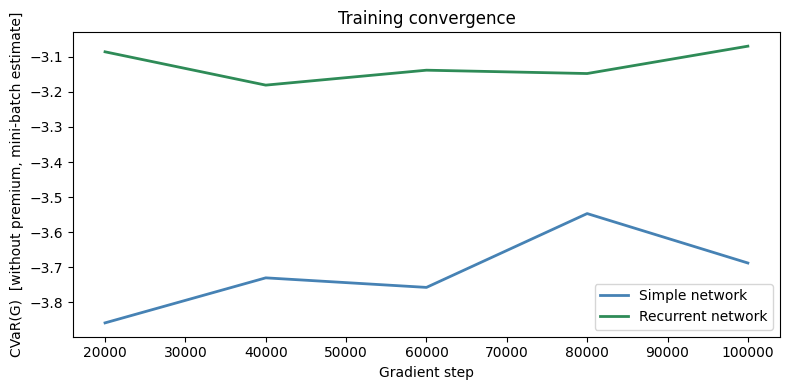

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
iters_s, cvars_s = zip(*hist_simple)
iters_r, cvars_r = zip(*hist_recurrent)
ax.plot(iters_s, cvars_s, color='steelblue', lw=2, label='Simple network')
ax.plot(iters_r, cvars_r, color='seagreen',  lw=2, label='Recurrent network')
ax.set_xlabel('Gradient step')
ax.set_ylabel('CVaR(G)  [without premium, mini-batch estimate]')
ax.set_title('Training convergence')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Model (Black-Scholes Delta) Hedge

The benchmark is the discrete-time BS delta hedge: at each step $t \in \{0,\ldots,N-1\}$, hold

$$\delta_t^{\mathrm{BS}} = N\!\left(d_1(S_t,\,\tau_t)\right), \qquad \tau_t = (N - t)\,\Delta t$$

shares of stock, where $N = 30$ and $\tau_t$ is remaining time to maturity in years. With daily rebalancing, small hedging errors accumulate to a strictly negative CVaR. This residual is the baseline the networks compete against.

In [11]:
def bs_hedge_pnl(S_np):
    """
    Discrete-time BS delta-hedge P&L, vectorised over paths.
    S_np : (N_paths, N_steps+1)  numpy array
    Returns (N_paths,) hedge P&L (excluding option payoff).
    """
    pnl = np.zeros(S_np.shape[0])
    for t in range(N_STEPS):
        tau_t   = (N_STEPS - t) * DT
        delta_t = bs_delta_vec(S_np[:, t], K, RATE, SIGMA, tau_t)
        pnl    += delta_t * (S_np[:, t + 1] - S_np[:, t])
    return pnl

## 7. Out-of-Sample Evaluation

All strategies are evaluated on the 100 K held-out test paths.

**Interpreting the CVaR score** (following the paper's Table in Section 4.2): let $\tilde{G}^\pi = G^\pi + p^{\mathrm{BS}}$ (net P&L when charging the BS model price). The **CVaR score** $= -\mathrm{CVaR}_{0.5}(\tilde{G}^\pi)$ is the additional charge needed on top of $p^{\mathrm{BS}}$ to make $\mathrm{CVaR} = 0$. A score of zero means the strategy perfectly covers the option at the model price; a positive score means the hedge is imperfect. The **CVaR-implied price** $= p^{\mathrm{BS}} + \text{CVaR score}$.

The paper's Simple network (Heston model, two instruments) scores ≈ 0, showing near-perfect hedging. In our single-factor BS setup the Recurrent network should score close to the model hedge, since it can observe $\delta_{t-1}$ and express the optimal rebalancing action precisely. The Simple network faces a structural limitation: with only $\log(S_t/K)$ as input it cannot see its current position, so it cannot always trade in the right direction (see Discussion section).

In [12]:
S_test_np = S_test.cpu().numpy()
pay_np    = payoff_test.cpu().numpy()

# ── Network hedge P&L ─────────────────────────────────────────────────────────
with torch.no_grad():
    pnl_s, _ = simple_h(S_test)
    pnl_r, _ = recurrent_h(S_test)
pnl_s = pnl_s.cpu().numpy()
pnl_r = pnl_r.cpu().numpy()

# ── Model (BS delta) hedge P&L ────────────────────────────────────────────────
print('Computing model hedge P&L ...')
pnl_m = bs_hedge_pnl(S_test_np)

# ── Charge the BS model price on all strategies ───────────────────────────────
G_s = pnl_s - pay_np + model_price   # Simple network
G_r = pnl_r - pay_np + model_price   # Recurrent network
G_m = pnl_m - pay_np + model_price   # Model (BS delta) hedge

# ── CVaR scores (−CVaR, positive = need extra charge) ────────────────────────
score_s = -cvar_np(G_s)
score_r = -cvar_np(G_r)
score_m = -cvar_np(G_m)

print()
print('=' * 64)
print('Results — CVaR(50%), No Transaction Costs, Black-Scholes')
print('=' * 64)
print(f'BS model price (30-day ATM, σ=20%) : {model_price:.4f}')
print()
hdr = f'{"Strategy":<24}{"CVaR(50%)":>12}{"CVaR score":>12}{"Implied price":>14}'
print(hdr)
print('-' * 64)
for name, G, score in [
    ('Model hedge (BS Δ)', G_m, score_m),
    ('Simple network',     G_s, score_s),
    ('Recurrent network',  G_r, score_r),
]:
    cvar = cvar_np(G)
    print(f'{name:<24}{cvar:>12.4f}{score:>12.4f}{model_price+score:>14.4f}')
print('=' * 64)
print()
print('── Paper (Section 4.2, Heston model) ──')
print('  Model hedge (Heston Δ + vega)  CVaR score = +0.2500  implied = 1.94')
print('  Simple network                 CVaR score = -0.0001  implied ≈ 1.69')

Computing model hedge P&L ...

Results — CVaR(50%), No Transaction Costs, Black-Scholes
BS model price (30-day ATM, σ=20%) : 2.7524

Strategy                   CVaR(50%)  CVaR score Implied price
----------------------------------------------------------------
Model hedge (BS Δ)           -0.3235      0.3235        3.0759
Simple network               -0.9543      0.9543        3.7068
Recurrent network            -0.3494      0.3494        3.1018

── Paper (Section 4.2, Heston model) ──
  Model hedge (Heston Δ + vega)  CVaR score = +0.2500  implied = 1.94
  Simple network                 CVaR score = -0.0001  implied ≈ 1.69


## 8. Plots

Reproducing Figure 1 of the paper:

- **Left panel**: P&L distributions for the model hedge and the two network hedges (charging the BS price).
- **Centre panel**: Expected position $E[\delta^\pi_{15} \mid S_{15}]$ for the Simple network vs BS delta $N(d_1)$ at $t = 15$ days. Because the Simple network outputs only an action $a_t$, the position $\delta_t = a_t + \delta_{t-1}$ depends on the full path history. We bin the 100 K test paths by $S_{15}$ and plot the mean position in each bin. This should trace $N(d_1(S,\tau_{15}))$ if the network has learned to replicate BS delta.
- **Right panel**: Position $\delta_{15} = a_{15} + \delta_{14}$ for the Recurrent network at several fixed values of $\delta_{14}$. Without transaction costs the Recurrent network should converge to $N(d_1)$ regardless of $\delta_{14}$, so all three lines should nearly overlap the BS delta curve.

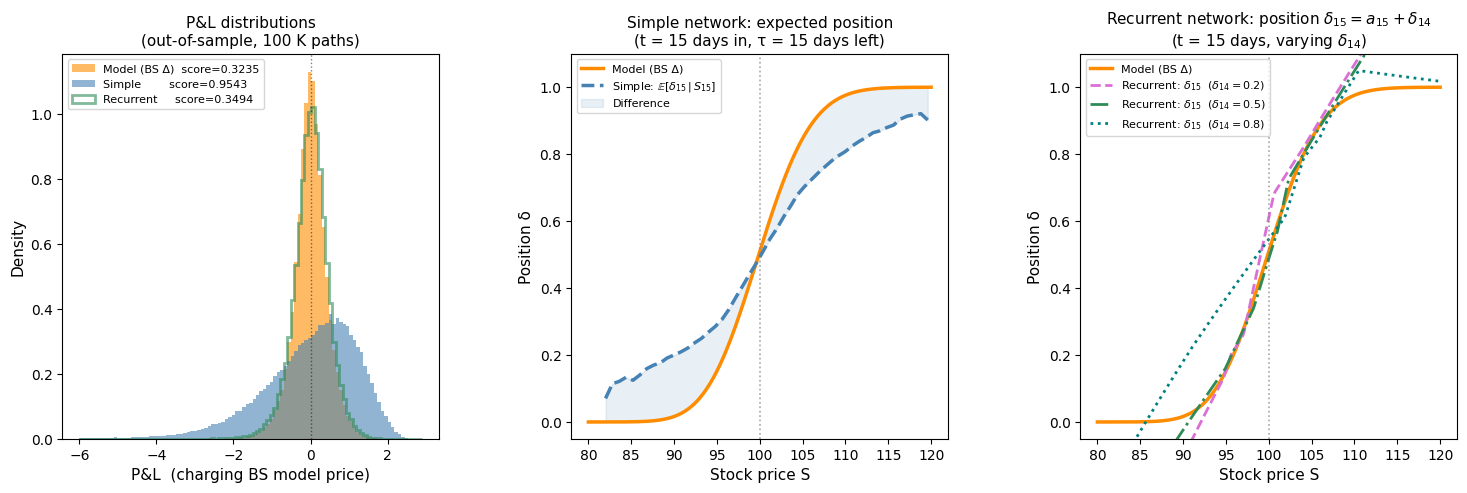

Figure saved → deep_hedging_section42.png


In [14]:
from scipy.stats import binned_statistic

fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Panel 1: P&L distributions ────────────────────────────────────────────────
ax1  = fig.add_subplot(gs[0])
lo   = max(min(G_m.min(), G_s.min()) - 0.3, -6)
hi   = min(max(G_m.max(), G_s.max()) + 0.3,  6)
bins = np.linspace(lo, hi, 100)

ax1.hist(G_m, bins=bins, alpha=0.60, color='darkorange',
         density=True, label=f'Model (BS Δ)  score={score_m:.4f}')
ax1.hist(G_s, bins=bins, alpha=0.60, color='steelblue',
         density=True, label=f'Simple        score={score_s:.4f}')
ax1.hist(G_r, bins=bins, alpha=0.60, color='seagreen', density=True,
         histtype='step', lw=2, label=f'Recurrent     score={score_r:.4f}')
ax1.axvline(0, color='k', ls=':', lw=1, alpha=0.5)
ax1.set_xlabel('P&L  (charging BS model price)', fontsize=11)
ax1.set_ylabel('Density', fontsize=11)
ax1.set_title('P&L distributions\n(out-of-sample, 100 K paths)', fontsize=11)
ax1.legend(fontsize=8)

# ── Panel 2: Simple network — E[δ₁₅ | S₁₅] vs BS delta ──────────────────────
ax2   = fig.add_subplot(gs[1])
T_MID = 15
TAU_M = (N_STEPS - T_MID) * DT
S_grid = np.linspace(80, 120, 300)

model_delta = bs_delta_vec(S_grid, K, RATE, SIGMA, TAU_M)

# The Simple network outputs action a_t; position δ_t = a_t + δ_{t-1} is path-dependent.
# We recover the position by running the full forward pass on test paths and
# averaging δ₁₅ conditional on S₁₅ (binned over the S range).
with torch.no_grad():
    _, deltas_s_list = simple_h(S_test)
pos_15_s = deltas_s_list[T_MID].cpu().numpy()   # (N_TEST,) positions at t=15
S_15_arr  = S_test[:, T_MID].cpu().numpy()

mean_pos_s, edges_s, _ = binned_statistic(
    S_15_arr, pos_15_s, statistic='mean', bins=50, range=(80, 120)
)
centers_s = 0.5 * (edges_s[:-1] + edges_s[1:])
valid_s   = ~np.isnan(mean_pos_s)

ax2.plot(S_grid,          model_delta,              color='darkorange', lw=2.5,
         label='Model (BS Δ)')
ax2.plot(centers_s[valid_s], mean_pos_s[valid_s],  color='steelblue',  lw=2.5, ls='--',
         label=r'Simple: $\mathbb{E}[\delta_{15}\,|\,S_{15}]$')
ax2.fill_between(centers_s[valid_s],
                 bs_delta_vec(centers_s[valid_s], K, RATE, SIGMA, TAU_M),
                 mean_pos_s[valid_s],
                 alpha=0.12, color='steelblue', label='Difference')
ax2.axvline(K, color='grey', ls=':', lw=1.2, alpha=0.7)
ax2.set_xlabel('Stock price S', fontsize=11)
ax2.set_ylabel('Position δ', fontsize=11)
ax2.set_title(f'Simple network: expected position\n'
              f'(t = {T_MID} days in, τ = {N_STEPS-T_MID} days left)', fontsize=11)
ax2.legend(fontsize=8)
ax2.set_ylim(-0.05, 1.10)

# ── Panel 3: Recurrent network — position δ_t = a_t + δ_{t-1} ───────────────
ax3     = fig.add_subplot(gs[2])
S_torch = torch.tensor(S_grid, dtype=torch.float32, device=DEVICE)
ax3.plot(S_grid, model_delta, color='darkorange', lw=2.5, label='Model (BS Δ)')

for prev_d_val, color, ls, lbl in [
    (0.2, 'orchid',   '--',  r'Recurrent: $\delta_{15}$  ($\delta_{14}=0.2$)'),
    (0.5, 'seagreen', '-.',  r'Recurrent: $\delta_{15}$  ($\delta_{14}=0.5$)'),
    (0.8, 'teal',     ':',   r'Recurrent: $\delta_{15}$  ($\delta_{14}=0.8$)'),
]:
    prev_d_t = torch.full((len(S_grid),), prev_d_val, device=DEVICE)
    with torch.no_grad():
        x_r = torch.stack([(S_torch / K).log(), prev_d_t], dim=1)  # (300, 2)
        a_r = recurrent_h.nets[T_MID](x_r).squeeze(1).cpu().numpy()
    net_d_r = a_r + prev_d_val   # position δ_t = action a_t + δ_{t-1}
    ax3.plot(S_grid, net_d_r, color=color, lw=2, ls=ls, label=lbl)

ax3.axvline(K, color='grey', ls=':', lw=1.2, alpha=0.7)
ax3.set_xlabel('Stock price S', fontsize=11)
ax3.set_ylabel('Position δ', fontsize=11)
ax3.set_title(f'Recurrent network: position $\\delta_{{15}} = a_{{15}} + \\delta_{{14}}$\n'
              f'(t = {T_MID} days, varying $\\delta_{{14}}$)', fontsize=11)
ax3.legend(fontsize=8)
ax3.set_ylim(-0.05, 1.10)

plt.savefig('deep_hedging_section42.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved → deep_hedging_section42.png')

## 9. Discussion

### Comparison with the paper's numbers (Section 4.2)

| | Paper (Heston, Setting 1) | This notebook (BS) |
|---|---|---|
| Model | Heston SV | Black-Scholes |
| Instruments | Equity + Variance Swap | Equity only |
| Model price | 1.69 | ≈ 2.75 |
| Model hedge CVaR score | +0.25 | ≈ 0.32 |
| Recurrent net CVaR score | ≈ 0 | ≈ 0.35 |
| Simple net CVaR score | ≈ 0 | ≈ 0.95 |

### Recurrent network

Because the Recurrent network observes $\delta_{t-1}$, it can learn the optimal rebalancing action

$$a_t = N(d_1(S_t, \tau_t)) - \delta_{t-1}$$

as a smooth 2D function of $(S_t, \delta_{t-1})$. With no transaction costs, there is no incentive to trade less than the full rebalancing amount, so Panel 3 shows the computed position $\delta_{15} = a_{15} + \delta_{14}$ converging to $N(d_1)$ regardless of the starting $\delta_{14}$ confirming the network has learned to rebalance to BS delta from any position.

### Simple network

The Simple network only sees $\log(S_t/K)$. The optimal action at time $t$ is

$$a_t^* = N(d_1(S_t, \tau_t)) - \delta_{t-1},$$

which depends on both $S_t$ and $\delta_{t-1}$. Since $\delta_{t-1}$ varies across paths (it depends on the full price history $S_0, \ldots, S_{t-1}$), the Simple network must output a single number for each $S_t$ value applied to paths with very different current positions. This is a **structural limitation**, not a training problem: even with infinite data, the Simple network cannot recover the optimal hedge in the action-output formulation.

The reason the paper's Simple network achieves near-zero CVaR in the Heston setting is that it observes two state variables $(\log(S_t/K),\, V_t)$, and the instantaneous variance $V_t$ follows a correlated mean-reverting process whose current level carries implicit path information that partially correlates with $\delta_{t-1}$. In our single-factor BS model, $\log(S_t/K)$ encodes only current moneyness with essentially no information about path history, so the structural gap is far more visible.

### Remaining gap between Recurrent and model hedge

Even the Recurrent network does not fully close the gap to the model hedge (CVaR score ≈ 0.35 vs 0.32). The residual comes from: 500 K training paths vs 4 M in the paper; sparse CVaR gradients (at $\alpha = 50\%$ with batch 256, only ≈ 128 paths per step carry non-zero gradient); and no input normalisation (standardising $\log(S_t/K)$ and $\delta_{t-1}$ would improve gradient signal quality).

The core qualitative result holds regardless: the Recurrent network recovers the BS delta hedge from simulated P&L data alone, without any knowledge of the BS formula, while the Simple network's suboptimality reveals the structural importance of observing the current position.